In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import mne 

from mi_decoder.data import load_subject

In [5]:
subject_data = load_subject(1)
raw_data = subject_data["0train"]["0"]

eeg_raw = raw_data.copy().pick(picks='eeg')
print(eeg_raw.info)
print(eeg_raw.get_data().shape)
# numpy_arr = raw_data.get_data()[0:22, :]
# print(numpy_arr.shape)

<Info | 11 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG
 custom_ref_applied: False
 description: Artifacts: 2/48 trials;
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 125.0 Hz
 meas_date: 2008-01-01 00:00:00 UTC
 nchan: 22
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | birthday: 1986-01-01, sex: 2, hand: 1, his_id: sub-01>
>
(22, 96735)


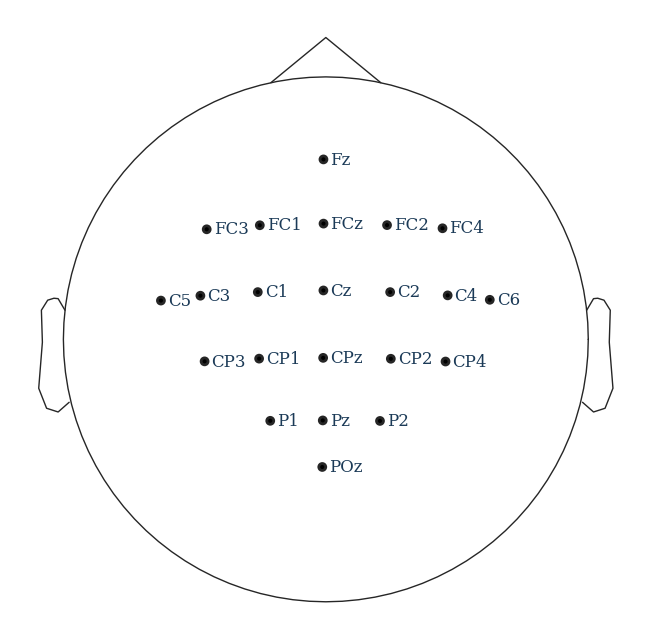

In [6]:
montage = mne.channels.make_standard_montage('standard_1020')
eeg_raw.set_montage(montage)
_ = eeg_raw.plot_sensors(show_names=True)


### Frequency

## Biological Ranges

1. 0-8Hz: slow drift, eye movements, non-motor cortical rhythms
2. 8-13Hz: sensorimotor cortex produces a strong mu rhythem -> you imagine moving a limb, mu decreases on the contralateral side
    - Mu Rhythm
    - Imagine right hand movement -> mu drops at C3 (left motor cortex)
3. 13-30Hz: Beta increases during imagery and often shows rebound increase afterward
    - Beta Rhythm 
    - Motor planning and execution 

## Digital Filter Designs
1. FIR (finite impulse response)
    - the filtered output at time t is a weighted sum of the last N input samples
    - the weights are called the filter coefficients or the impulse response
    - The longer the filter (Bigger N), the sharper the transition between passband and stopband, but the higher the latency

2. IIR (infinite impulse response)
    - the filtered output at time t is a weighted sum of the past inputs and past outputs (recursive)
    - much more efficient, sharp filter with fewer coefficients 
    - recursive feedback can cause subtle issues, worse phase behavior, numerical instability if designed wrong

* For EEG offline analysis, use FIR
    - can be made linear phase -> when did the motor imagery start relative to the cue?

3. Zero phase filtering
    - even if linear-phase FIR filter delays the signal by some number of samples, the delay itself is still a problem
* Solution: Filter forwards, then filter backwards. 
    - forward pass delays by k, backwards pass delays by -k -> net 0 Delay
    - frequency magnitude response gets squared, so filter is actually sharper
* Since its acausal, it doesn't work for real time filtering


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/jakkolb/Desktop/Coding/GitHub/bci-iv-2a-decoding/.venv/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


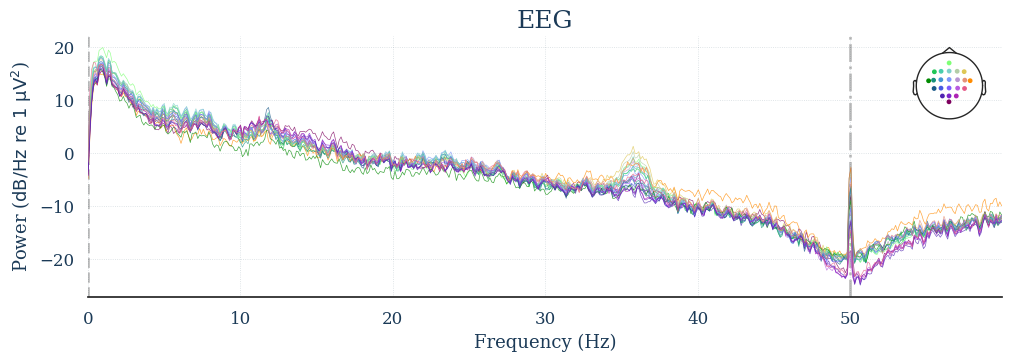

In [7]:
_ = eeg_raw.compute_psd(fmax=60).plot()


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/jakkolb/Desktop/Coding/GitHub/bci-iv-2a-decoding/.venv/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


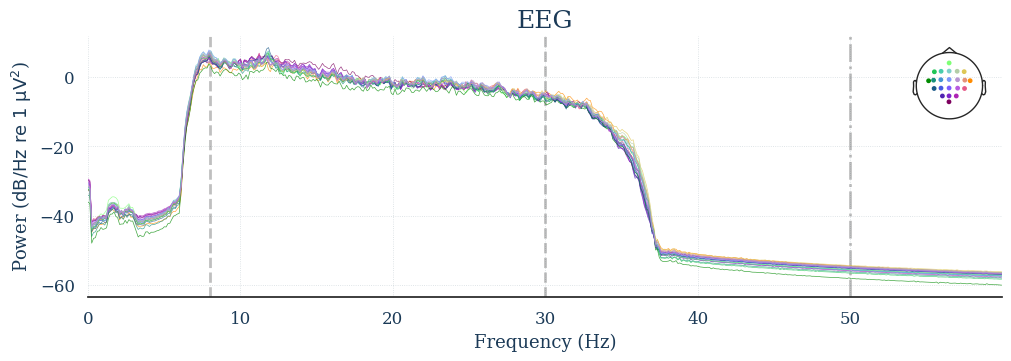

In [8]:
filtered_raw = eeg_raw.copy().filter(l_freq=8, h_freq=30).compute_psd(fmax=60).plot()

In [9]:
print(montage.get_positions().keys())
print(type(montage.get_positions()['ch_pos']))
print(montage.get_positions()['ch_pos']['Cz'])
print(montage.get_positions()['ch_pos'])
print(eeg_raw.get_data().shape)

dict_keys(['ch_pos', 'coord_frame', 'nasion', 'lpa', 'rpa', 'hsp', 'hpi'])
<class 'collections.OrderedDict'>
[ 0.0004009 -0.009167   0.100244 ]
OrderedDict([('Fp1', array([-0.0294367,  0.0839171, -0.00699  ])), ('Fpz', array([ 0.0001123,  0.088247 , -0.001713 ])), ('Fp2', array([ 0.0298723,  0.0848959, -0.00708  ])), ('AF9', array([-0.0489708,  0.0640872, -0.047683 ])), ('AF7', array([-0.0548397,  0.0685722, -0.01059  ])), ('AF5', array([-0.0454307,  0.0728622,  0.005978 ])), ('AF3', array([-0.0337007,  0.0768371,  0.021227 ])), ('AF1', array([-0.0184717,  0.0799041,  0.032752 ])), ('AFz', array([0.0002313, 0.080771 , 0.035417 ])), ('AF2', array([0.0198203, 0.0803019, 0.032764 ])), ('AF4', array([0.0357123, 0.0777259, 0.021956 ])), ('AF6', array([0.0465843, 0.0738078, 0.006034 ])), ('AF8', array([ 0.0557433,  0.0696568, -0.010755 ])), ('AF10', array([ 0.0504352,  0.0638698, -0.048005 ])), ('F9', array([-0.0701019,  0.0416523, -0.049952 ])), ('F7', array([-0.0702629,  0.0424743, -0.0114

In [10]:
eeg_raw.filter(l_freq=8, h_freq=30)
events, event_id = mne.events_from_annotations(eeg_raw)

epochs = mne.Epochs(
    eeg_raw,
    events=events,
    event_id=event_id,
    tmin=-0.5,
    tmax=4.0,
    baseline=(-0.5, 0),
    preload=True, # forces data into memory now, otherwise epochs stores references to raw and re-reads each epoch 
)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Not setting metadata
48 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 48 events and 1126 original time points ...
0 bad epochs dropped


In [11]:
print(epochs)
print(epochs.get_data().shape)  # should be (48, 22, 1126)
print(epochs.events[:5])

<Epochs | 48 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~9.1 MiB, data loaded,
 np.str_('feet'): 12
 np.str_('left_hand'): 12
 np.str_('right_hand'): 12
 np.str_('tongue'): 12>
(48, 22, 1126)
[[ 750    0    4]
 [2753    0    1]
 [4671    0    3]
 [6623    0    2]
 [8631    0    2]]


In [12]:
X = epochs.get_data()
Y = epochs.events[:, 2]
# print(type(X))
# print(type(Y))
print(X.shape, Y.shape)
print(type(X), type(Y))
print("class counts:", np.bincount(Y))

(48, 22, 1126) (48,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
class counts: [ 0 12 12 12 12]


In [21]:
epochs = mne.Epochs(eeg_raw, events, event_id=event_id,
                    tmin=-0.5, tmax=4.0, baseline=None, preload=True)

X = epochs.get_data() # shape (48, 22, 1126) = (n_epochs, n_channels, n_times)
times = epochs.times # 250 * 4.5 + 1= 1126 times from -0.5 to 4.0 seconds

baseline_mask = (times >= -0.5) & (times < 0.0)
imagery_mask  = (times >= 0.5) & (times <= 2.5)
# baseline_mask.sum(), imagery_mask.sum()

P_baseline = (X[: , : , baseline_mask] ** 2).mean(axis=2)
P_imagery = (X[: , : , imagery_mask] ** 2).mean(axis=2)
print(P_baseline.shape, P_imagery.shape)

Not setting metadata
48 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 48 events and 1126 original time points ...
0 bad epochs dropped
(48, 22) (48, 22)


In [37]:
classes = {"left_hand": 0, "right_hand": 1, "feet": 2, "tongue": 3}

mne_codes = epochs.events[:, 2]

erd_per_class = {}
for class_name, _ in classes.items():
    code = event_id[class_name]
    trial_mask = (mne_codes == code)
    
    P_b = P_baseline[trial_mask].mean(axis=0)
    P_i = P_imagery[trial_mask].mean(axis=0)
    erd = (P_i - P_b) / P_b
    erd_per_class[class_name] = erd
    
# print(erd_per_class.keys())
# print(P_baseline[0][0])
# print(trial_mask)
    
    

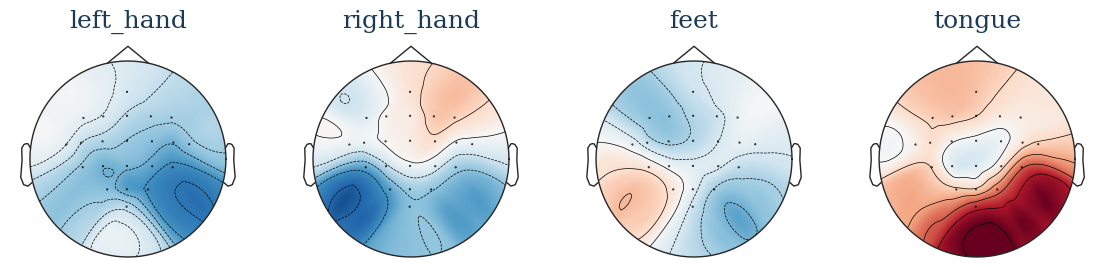

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (class_name, erd) in zip(axes, erd_per_class.items()):
    mne.viz.plot_topomap(erd, epochs.info, axes=ax, show=False, cmap='RdBu_r', vlim=(-0.5, 0.5)) # blue is negative ERD
    ax.set_title(class_name)
    # ax.set_yticks([])
plt.show()